In [40]:
# 1. Import library
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
import smote_variants as sv
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


In [41]:
df = pd.read_csv("framingham.csv")

In [42]:
# 3. Pilih 8 fitur utama
selected_features = [
"male", "age", "currentSmoker", "cigsPerDay", "BPMeds", 
    "prevalentHyp", "diabetes", "totChol", 
    "sysBP", "glucose"
]

In [43]:

target_col = "TenYearCHD"

# Pastikan semua kolom ada
print("Kolom yang digunakan:")
print(selected_features + [target_col])
print(df[selected_features + [target_col]].head())

Kolom yang digunakan:
['male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'glucose', 'TenYearCHD']
   male  age  currentSmoker  cigsPerDay  BPMeds  prevalentHyp  diabetes  \
0     1   39              0         0.0     0.0             0         0   
1     0   46              0         0.0     0.0             0         0   
2     1   48              1        20.0     0.0             0         0   
3     0   61              1        30.0     0.0             1         0   
4     0   46              1        23.0     0.0             0         0   

   totChol  sysBP  glucose  TenYearCHD  
0    195.0  106.0     77.0           0  
1    250.0  121.0     76.0           0  
2    245.0  127.5     70.0           0  
3    225.0  150.0    103.0           1  
4    285.0  130.0     85.0           0  


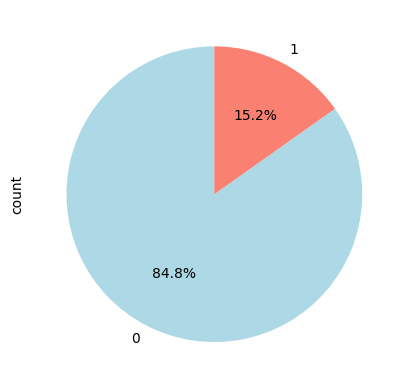

In [44]:
target_counts = df[target_col].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, colors=["lightblue", "salmon"])

In [45]:
# 5. Pre-processing

# Imputasi mean untuk missing values di fitur + target (kalau ada)
for col in selected_features + [target_col]:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

X = df[selected_features]
y = df[target_col].astype(int)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [46]:
# 6. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=y
)

In [47]:

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Distribusi kelas train:")
print(pd.Series(y_train).value_counts(normalize=True))
print("Distribusi kelas test:")
print(pd.Series(y_test).value_counts(normalize=True))

Train shape: (3816, 10) Test shape: (424, 10)
Distribusi kelas train:
TenYearCHD
0    0.848008
1    0.151992
Name: proportion, dtype: float64
Distribusi kelas test:
TenYearCHD
0    0.849057
1    0.150943
Name: proportion, dtype: float64


In [48]:
# 7. Definisi SMOTE-IPF

class SMOTE_IPF(BaseEstimator, TransformerMixin):
    def __init__(self, sampling_strategy=1.0, smote_k=5, ipf_k=3,
                 max_iter=5, random_state=None, verbose=False):
        self.sampling_strategy = sampling_strategy
        self.smote_k = smote_k
        self.ipf_k = ipf_k
        self.max_iter = max_iter
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y=None):
        return self

    def fit_resample(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y).ravel()

        smote = SMOTE(
            sampling_strategy=self.sampling_strategy,
            k_neighbors=self.smote_k,
            random_state=self.random_state
        )
        X_res, y_res = smote.fit_resample(X, y)

        for it in range(self.max_iter):
            knn = KNeighborsClassifier(n_neighbors=self.ipf_k)
            knn.fit(X_res, y_res)
            y_pred = knn.predict(X_res)

            misclassified = y_pred != y_res
            if not np.any(misclassified):
                if self.verbose:
                    print(f"Iterasi {it+1}: tidak ada noise, berhenti.")
                break

            minority_class = 1 if np.sum(y_res == 1) < np.sum(y_res == 0) else 0
            idx_noise = np.where(misclassified & (y_res == minority_class))[0]

            if len(idx_noise) == 0:
                if self.verbose:
                    print(f"Iterasi {it+1}: tidak ada noise di kelas minoritas, berhenti.")
                break

            if self.verbose:
                print(f"Iterasi {it+1}: menghapus {len(idx_noise)} sampel noise.")

            mask_keep = np.ones(len(X_res), dtype=bool)
            mask_keep[idx_noise] = False
            X_res = X_res[mask_keep]
            y_res = y_res[mask_keep]

        return X_res, y_res

In [49]:
# 8. Fungsi evaluasi

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

results = []

In [50]:
# 9. Skenario 1: Baseline (tanpa oversampling)

svm_baseline = SVC(
    kernel="linear",
    C=10,
    gamma=1,
    random_state=RANDOM_STATE
)
svm_baseline.fit(X_train, y_train)
y_pred_baseline = svm_baseline.predict(X_test)

results.append(evaluate_model("SVM Baseline (Tanpa Oversampling)", y_test, y_pred_baseline))


=== SVM Baseline (Tanpa Oversampling) ===
Accuracy : 0.8490566037735849
Precision: 0.0
Recall   : 0.0
F1-score : 0.0

Confusion Matrix:
[[360   0]
 [ 64   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       360
           1       0.00      0.00      0.00        64

    accuracy                           0.85       424
   macro avg       0.42      0.50      0.46       424
weighted avg       0.72      0.85      0.78       424



In [51]:
# 10. Skenario 2: SMOTE

smote = SMOTE(
    sampling_strategy=0.5,
    random_state=RANDOM_STATE
)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

svm_smote = SVC(
    kernel="rbf",
    C=10,
    gamma=1,
    random_state=RANDOM_STATE
)
svm_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = svm_smote.predict(X_test)

results.append(evaluate_model("SVM + SMOTE", y_test, y_pred_smote))


=== SVM + SMOTE ===
Accuracy : 0.7924528301886793
Precision: 0.2777777777777778
Recall   : 0.234375
F1-score : 0.2542372881355932

Confusion Matrix:
[[321  39]
 [ 49  15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       360
           1       0.28      0.23      0.25        64

    accuracy                           0.79       424
   macro avg       0.57      0.56      0.57       424
weighted avg       0.78      0.79      0.79       424



In [52]:
# 11. Skenario 3: SMOTE-IPF

smote_ipf = SMOTE_IPF(
    sampling_strategy=0.75,
    smote_k=150,
    ipf_k=150,
    max_iter=50,
    random_state=RANDOM_STATE,
    verbose=False
)
X_train_smote_ipf, y_train_smote_ipf = smote_ipf.fit_resample(X_train, y_train)

svm_smote_ipf = SVC(
    class_weight='balanced',
    kernel="rbf",
    C=10,
    gamma="scale",
    random_state=RANDOM_STATE
)
svm_smote_ipf.fit(X_train_smote_ipf, y_train_smote_ipf)
y_pred_smote_ipf = svm_smote_ipf.predict(X_test)

results.append(evaluate_model("SVM + SMOTE-IPF", y_test, y_pred_smote_ipf))


=== SVM + SMOTE-IPF ===
Accuracy : 0.8278301886792453
Precision: 0.3448275862068966
Recall   : 0.15625
F1-score : 0.21505376344086022

Confusion Matrix:
[[341  19]
 [ 54  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       360
           1       0.34      0.16      0.22        64

    accuracy                           0.83       424
   macro avg       0.60      0.55      0.56       424
weighted avg       0.79      0.83      0.80       424

